<a href="https://colab.research.google.com/github/muslimhidayat7-debug/Kecerdasan-Buatan-Tugas-3/blob/main/MuslimHidayat_Assigment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Rule base (Sugeno output berupa angka)
rule_table = {
    ("Sedikit", "Kecil"): 1.2,
    ("Sedikit", "Menengah"): 1.8,
    ("Sedikit", "Besar"): 2.5,

    ("Sedang", "Kecil"): 1.5,
    ("Sedang", "Menengah"): 2.2,
    ("Sedang", "Besar"): 3.0,

    ("Banyak", "Kecil"): 1.8,
    ("Banyak", "Menengah"): 2.6,
    ("Banyak", "Besar"): 3.5
}

In [6]:
import pandas as pd

# Data sesuai rule table kamu
data = {
    "Kecil (280)": [1.2, 1.5, 1.8],
    "Menengah (530)": [1.8, 2.2, 2.6],
    "Besar (680)": [2.5, 3.0, 3.5]
}

index = ["Sedikit (1.5)", "Sedang (2.4)", "Banyak (3.0)"]

df = pd.DataFrame(data, index=index)

df

,Kecil (280),Menengah (530),Besar (680)
Sedikit (1.5),1.2,1.8,2.5
Sedang (2.4),1.5,2.2,3.0
Banyak (3.0),1.8,2.6,3.5


fuzzy_area
[0. 0. 1.]
fuzzy_daya
[0.4 0.  0. ]
crisp_output
1.8
Paket: Premium


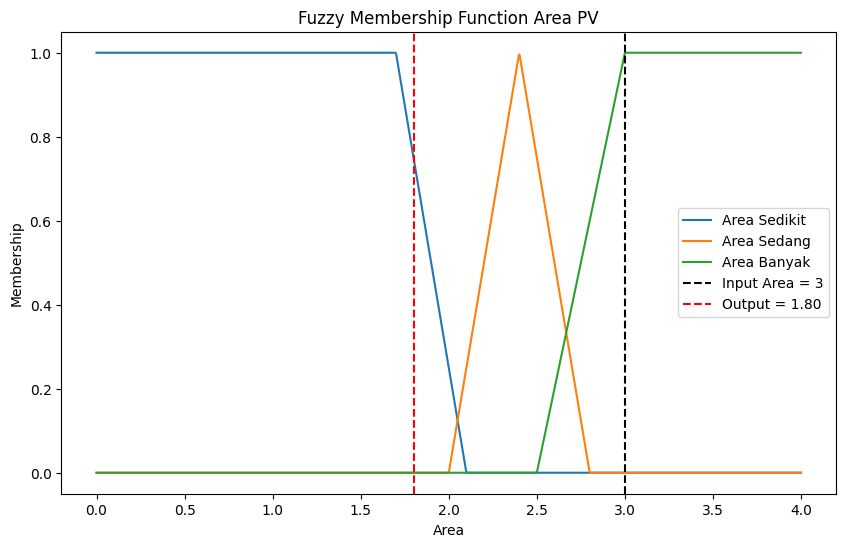

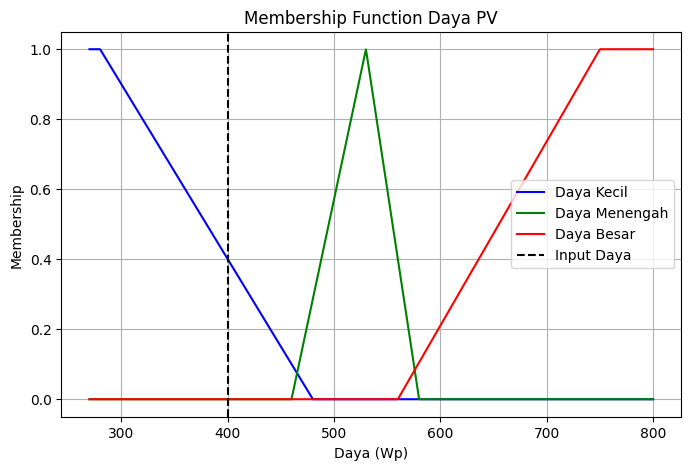

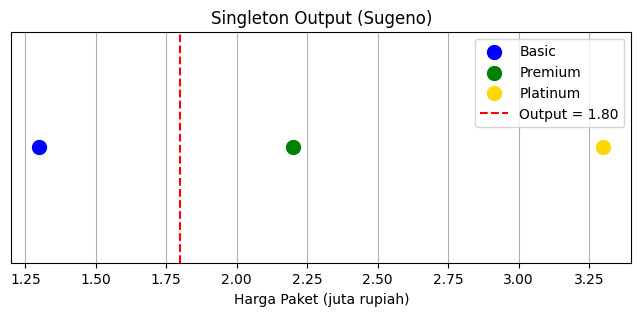

In [1]:
#Assignment 3: Kuliah Kecerdasan Buatan
#Coding: Create 3 membership functions to do a fuzzification 2 input and 1 output for PV Panel
#Nama :Muslim Hidayat
#NRP  :6022251058

import numpy as np
import matplotlib.pyplot as plt

def triangle(x, a, b, c, d, e):
    """
    Calculates the membership value for a triangular fuzzy function using if/elif/else.

    Parameters:
    x (float or np.array): The input value(s).
    a (float): The left-most X point, paired with y value d.
    b (float): The middle X point, paired with Y value of 1.
    c (float): The right-most X point, paired with Y value e.
    d (float): The y-value at point a.
    e (float): The y-value at point c.

    Returns:
    float or np.array: The membership value(s).
    """

    if x < a:
        return d
    elif a <= x <= b:
        return (x - a) / (b - a)
    elif b < x <= c:
        return (c - x) / (c - b)
    elif x > c:
        return e
    else:
        return 0

# Membership function area (m2)
def fuzifikasi_area(x):
  sedikit = triangle(x, 1.7, 1.7, 2.1, 1, 0)
  sedang = triangle(x, 2.0, 2.4, 2.8, 0, 0)
  banyak = triangle(x, 2.5, 3.0, 0, 0, 1)
  return np.array([sedikit, sedang,  banyak])

#membership function daya (dalam Wp)
def fuzifikasi_daya(x):
  kecil = triangle(x, 280, 280, 480, 1, 0)
  menengah = triangle(x, 460, 530, 580, 0, 0)
  besar = triangle(x, 560, 750, 0, 0, 1)
  return np.array([kecil, menengah, besar])


#Inputan
in_fuzzy_area = 3
in_fuzzy_daya = 400

fuzzy_area = fuzifikasi_area(in_fuzzy_area)
fuzzy_daya = fuzifikasi_daya(in_fuzzy_daya)

#Rule Singleton (output dalam juta rupiah)
rule_FD = np.array([[1.2, 1.8, 2.5],
                    [1.5, 2.2, 3.0],
                    [1.8, 2.6, 3.5]])

num = 0
denum = 0

for i, val_area in enumerate(fuzzy_area):
  for j, val_daya in enumerate(fuzzy_daya):
    min_val = min (val_area, val_daya)
    num = num + min_val * rule_FD[i][j]
    denum = denum + min_val

crisp_output = num/denum

print("fuzzy_area")
print(fuzzy_area)
print("fuzzy_daya")
print(fuzzy_daya)
print("crisp_output")
print(crisp_output)

if crisp_output < 1.8:
    paket = "Basic"
elif crisp_output < 3:
    paket = "Premium"
else:
    paket = "Platinum"

print("Paket:", paket)

#Plot untuk Area
semua_area = np.linspace(0, 4, 1000)
semua_FD_fuzzy_area = np.zeros((len(semua_area),3))

for i, val in enumerate(semua_area):
  semua_FD_fuzzy_area[i] = fuzifikasi_area(val)

plt.figure(figsize=(10, 6))
plt.plot(semua_area,semua_FD_fuzzy_area[:,0],label="Area Sedikit")
plt.plot(semua_area,semua_FD_fuzzy_area[:,1],label="Area Sedang")
plt.plot(semua_area,semua_FD_fuzzy_area[:,2],label="Area Banyak")

plt.axvline(in_fuzzy_area, color='black', linestyle='--', label=f'Input Area = {in_fuzzy_area}')
plt.axvline(crisp_output, color='red', linestyle='--', label=f'Output = {crisp_output:.2f}')

plt.legend()
plt.xlabel("Area")
plt.ylabel("Membership")
plt.title("Fuzzy Membership Function Area PV")
plt.show()

#Plot untuk Daya
semua_daya = np.linspace(270,800,1000)
FD_daya = np.zeros((len(semua_daya),3))

for i,val in enumerate(semua_daya):
    FD_daya[i]=fuzifikasi_daya(val)

plt.figure(figsize=(8,5))

plt.plot(semua_daya,FD_daya[:,0],label="Daya Kecil",color="blue")
plt.plot(semua_daya,FD_daya[:,1],label="Daya Menengah",color="green")
plt.plot(semua_daya,FD_daya[:,2],label="Daya Besar",color="red")

plt.axvline(in_fuzzy_daya,color='black',linestyle='--',label="Input Daya")
#plt.axvline(crisp_output, color='red', linestyle='--', label=f'Output = {crisp_output:.2f}')

plt.title("Membership Function Daya PV")
plt.xlabel("Daya (Wp)")
plt.ylabel("Membership")
plt.legend()
plt.grid()

plt.show()

#Plot untuk Sugeno
plt.figure(figsize=(8,3))

plt.scatter([1.3],[1],color='blue',s=100,label="Basic")
plt.scatter([2.2],[1],color='green',s=100,label="Premium")
plt.scatter([3.3],[1],color='gold',s=100,label="Platinum")

plt.axvline(crisp_output,color='red',linestyle='--',label=f'Output = {crisp_output:.2f}')

plt.yticks([])
plt.xlabel("Harga Paket (juta rupiah)")
plt.title("Singleton Output (Sugeno)")
plt.legend()
plt.grid()

plt.show()